# CNN Training and Grad-CAM Visualization

This notebook demonstrates how to train a Convolutional Neural Network (CNN) on the CIFAR-10 dataset and use **Grad-CAM** (Gradient-weighted Class Activation Mapping) to visualize which parts of an image the model uses to make its predictions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import cv2

# Load and preprocess CIFAR-10
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training data shape: {train_images.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 134s 1us/step
Training data shape: (50000, 32, 32, 3)


## Build and Train the CNN
We'll use a standard CNN architecture with several convolutional and pooling layers.

In [12]:
inputs = layers.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu', name='last_conv_layer')(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(10)(x)

model = models.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Training for 5 epochs
history = model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 41ms/step - accuracy: 0.4496 - loss: 1.5084 - val_accuracy: 0.5677 - val_loss: 1.2093
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.5987 - loss: 1.1311 - val_accuracy: 0.6315 - val_loss: 1.0334
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 41ms/step - accuracy: 0.6575 - loss: 0.9805 - val_accuracy: 0.6406 - val_loss: 1.0202
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - accuracy: 0.6891 - loss: 0.8855 - val_accuracy: 0.6890 - val_loss: 0.9058
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.7157 - loss: 0.8128 - val_accuracy: 0.6968 - val_loss: 0.8672


## Implementing Grad-CAM


In [9]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img * 255
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)
    return superimposed_img

## Visualization


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_35']
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Actual Class: dog
Predicted Class: dog (62.05%)


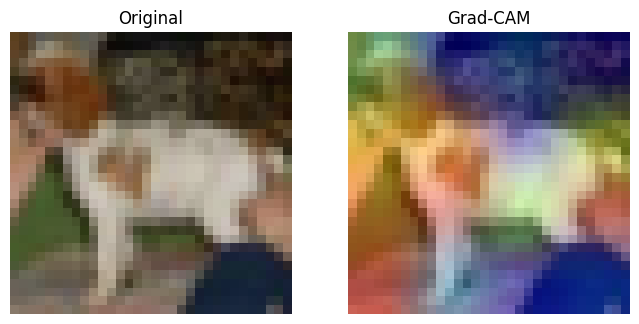

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Choose an index from the test set
img_idx = 12
sample_img = test_images[img_idx]
img_array = np.expand_dims(sample_img, axis=0)

# Prepare the heatmap using the updated model
# Note: we use the make_gradcam_heatmap defined in cell 627086fa
heatmap = make_gradcam_heatmap(img_array, model, "last_conv_layer")

# Display predictions
preds = model.predict(img_array)
pred_class = np.argmax(preds[0])
actual_class = test_labels[img_idx][0]

print(f"Actual Class: {class_names[actual_class]}")
print(f"Predicted Class: {class_names[pred_class]} ({tf.nn.softmax(preds)[0][pred_class]:.2%})")

# Superimpose and show
final_img = display_gradcam(sample_img, heatmap)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(sample_img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Grad-CAM")
plt.imshow(final_img)
plt.axis('off')
plt.show()